# Imports

In [1]:
import os                                     # for working with files
import numpy as np                            # for numerical computationss
import pandas as pd                           # for working with dataframes
import torch                                  # Pytorch module
import matplotlib.pyplot as plt               # for plotting informations on graph and images using tensors
import torch.nn as nn                         # for creating  neural networks
from torch.utils.data import DataLoader       # for dataloaders
from PIL import Image                         # for checking images
import torch.nn.functional as F               # for functions for calculating loss
import torchvision.transforms as transforms   # for transforming images into tensors
from torchvision.utils import make_grid       # for data checking
from torchvision.datasets import ImageFolder  # for working with classes and images
from torchsummary import summary              # for getting the summary of our model
import seaborn as sns
import tensorflow as tf

%matplotlib inline

In [2]:
# Check for GPU
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
# This will list all GPUs available
physical_devices = tf.config.experimental.list_physical_devices('GPU')
for device in physical_devices:
    tf.config.experimental.set_memory_growth(device, True)

Num GPUs Available:  1


# Data Exploration

In [3]:
#Download the dataset from kaggle
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [02:05<00:00, 23.1MB/s]



In [4]:
%%capture
# prompt: Unzip the downloaded file
!unzip new-plant-diseases-dataset.zip

In [5]:
data_dir = "New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
train_dir = "New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
valid_dir = "New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"
classes = os.listdir(train_dir)

In [6]:
print("The number of classes in the dataset is :",len(classes))
print("The classes in the dataset are :")
for i in range(len(classes)):
    print(classes[i])

The number of classes in the dataset is : 38
The classes in the dataset are :
Apple___healthy
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Potato___Late_blight
Tomato___Target_Spot
Grape___Black_rot
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Tomato___Leaf_Mold
Tomato___Bacterial_spot
Pepper,_bell___healthy
Tomato___healthy
Blueberry___healthy
Peach___Bacterial_spot
Apple___Black_rot
Corn_(maize)___healthy
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Strawberry___Leaf_scorch
Potato___healthy
Apple___Apple_scab
Grape___healthy
Cherry_(including_sour)___Powdery_mildew
Peach___healthy
Potato___Early_blight
Cherry_(including_sour)___healthy
Pepper,_bell___Bacterial_spot
Soybean___healthy
Tomato___Tomato_mosaic_virus
Strawberry___healthy
Apple___Cedar_apple_rust
Raspberry___healthy
Tomato___Late_blight
Orange___Haunglongbing_(Citrus_greening)
Grape___Esca_(Black_Measles)
Corn_(maize)___Northern_Leaf_Blight
Squash___Powdery_mildew
Tomato___Septori

In [7]:
plants = []
diseases = []
for plant in classes:
    if plant.split('___')[0] not in plants:
        plants.append(plant.split('___')[0])
    if plant.split('___')[1] != 'healthy' and plant.split('___')[1] not in diseases:
        diseases.append(plant.split('___')[1])

In [8]:
print("The number of plants in the dataset is :",len(plants))
print("The plants in the dataset are :")
for i in range(len(plants)):
    print(plants[i])

The number of plants in the dataset is : 14
The plants in the dataset are :
Apple
Tomato
Potato
Grape
Corn_(maize)
Pepper,_bell
Blueberry
Peach
Strawberry
Cherry_(including_sour)
Soybean
Raspberry
Orange
Squash


In [9]:
print("The number of diseases in the dataset is :",len(diseases))
print("The diseases in the dataset are :")
for i in range(len(diseases)):
    print(diseases[i])

The number of diseases in the dataset is : 20
The diseases in the dataset are :
Spider_mites Two-spotted_spider_mite
Tomato_Yellow_Leaf_Curl_Virus
Late_blight
Target_Spot
Black_rot
Cercospora_leaf_spot Gray_leaf_spot
Leaf_Mold
Bacterial_spot
Leaf_blight_(Isariopsis_Leaf_Spot)
Leaf_scorch
Apple_scab
Powdery_mildew
Early_blight
Tomato_mosaic_virus
Cedar_apple_rust
Haunglongbing_(Citrus_greening)
Esca_(Black_Measles)
Northern_Leaf_Blight
Septoria_leaf_spot
Common_rust_


In [10]:
# Number of images for each class
nums = {}
for c in classes:
    nums[c] = len(os.listdir(train_dir + '/' + c))

# converting the nums dictionary to pandas dataframe passing index as plant name and number of images as column
img_per_class = pd.DataFrame(nums.values(), index=nums.keys(), columns=["no. of images"])

In [11]:
img_per_class

,no. of images
Apple___healthy,2008
Tomato___Spider_mites Two-spotted_spider_mite,1741
Tomato___Tomato_Yellow_Leaf_Curl_Virus,1961
Potato___Late_blight,1939
Tomato___Target_Spot,1827
Grape___Black_rot,1888
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,1642
Tomato___Leaf_Mold,1882
Tomato___Bacterial_spot,1702
"Pepper,_bell___healthy",1988


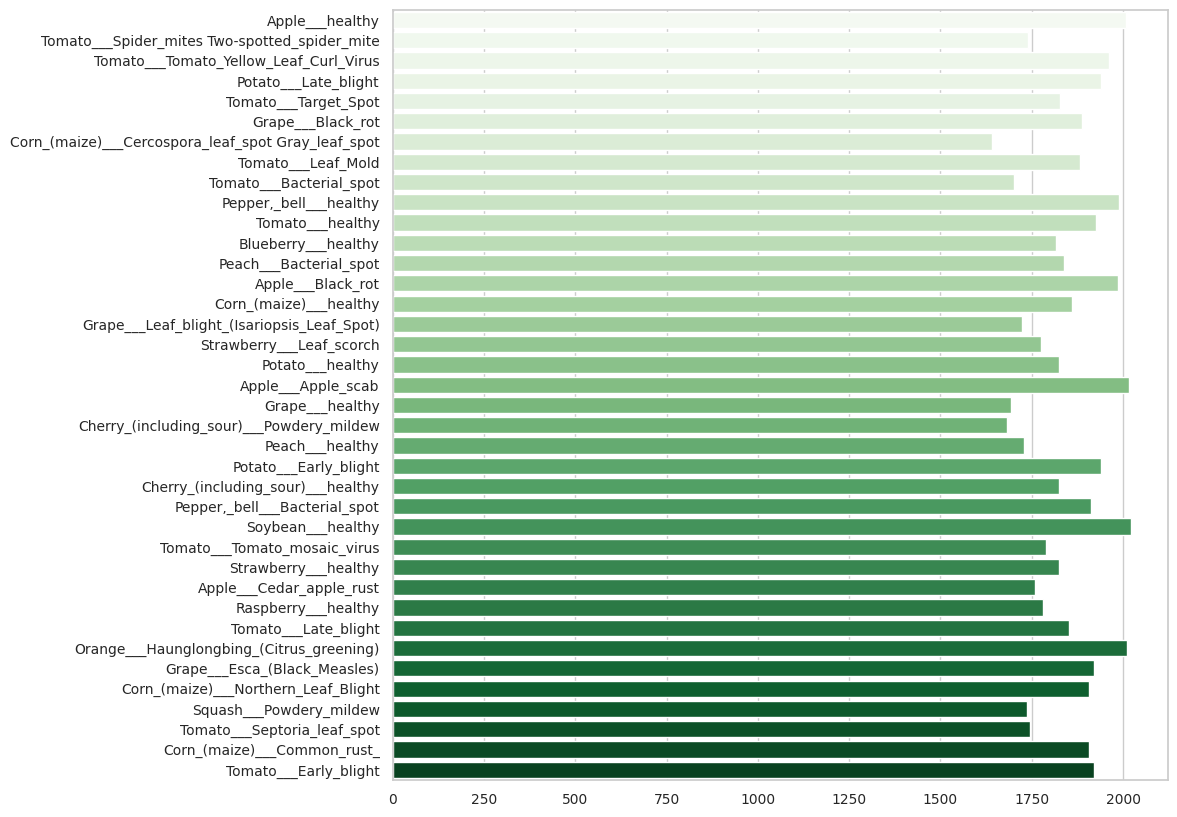

"\nindex = [n for n in range(38)]\nplt.figure(figsize=(20, 5))\nplt.bar(index, [n for n in nums.values()], width=0.3)\nplt.xlabel('Plants/Diseases', fontsize=10)\nplt.ylabel('No of images available', fontsize=10)\nplt.xticks(index, classes, fontsize=5, rotation=90)\nplt.title('Images per each class')\n"

In [15]:
# plotting number of images available for each disease
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid", color_codes=True)
plt.figure(figsize=(10,10),dpi=100)
ax = sns.barplot(x=  [n for n in nums.values()], y= classes, palette="Greens")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

"""
index = [n for n in range(38)]
plt.figure(figsize=(20, 5))
plt.bar(index, [n for n in nums.values()], width=0.3)
plt.xlabel('Plants/Diseases', fontsize=10)
plt.ylabel('No of images available', fontsize=10)
plt.xticks(index, classes, fontsize=5, rotation=90)
plt.title('Images per each class')
"""

# Preprocessing

In [ ]:
n_train = 0
for i in nums.values():
    n_train += i
print("The number of training images is :",n_train)

The number of training images is : 70295


In [ ]:
training_set = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True,
)

Found 70295 files belonging to 38 classes.


In [ ]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True,
)

Found 17572 files belonging to 38 classes.


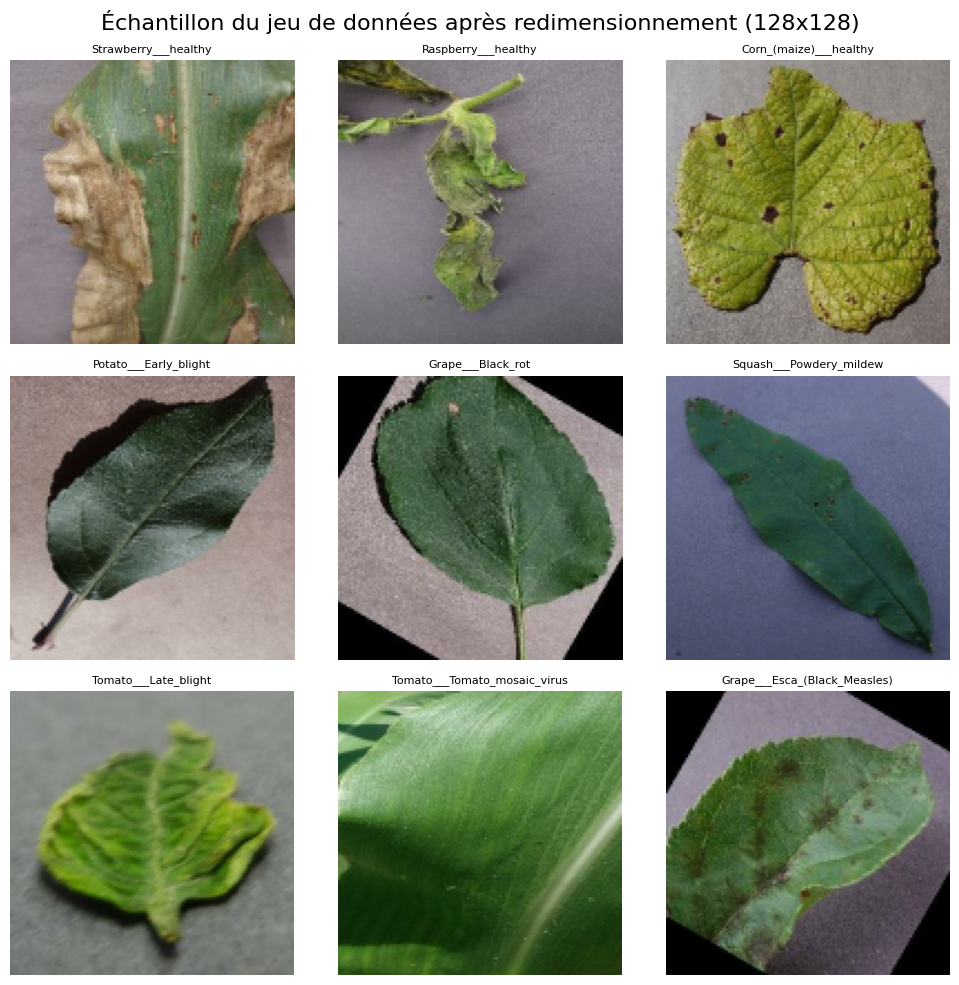

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

# Visualisation d'un lot d'images avec leurs classes
plt.figure(figsize=(10, 10))
for images, labels in training_set.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Conversion du tenseur float en entier pour l'affichage matplotlib
        plt.imshow(images[i].numpy().astype("uint8"))

        # Trouver l'index de la classe
        class_idx = tf.argmax(labels[i]).numpy()
        plt.title(classes[class_idx], fontsize=8)
        plt.axis("off")
plt.suptitle("Échantillon du jeu de données après redimensionnement (128x128)", fontsize=16)
plt.tight_layout()

# Sauvegarde de l'image pour le rapport LaTeX
plt.savefig('echantillon_dataset.png')
plt.show()

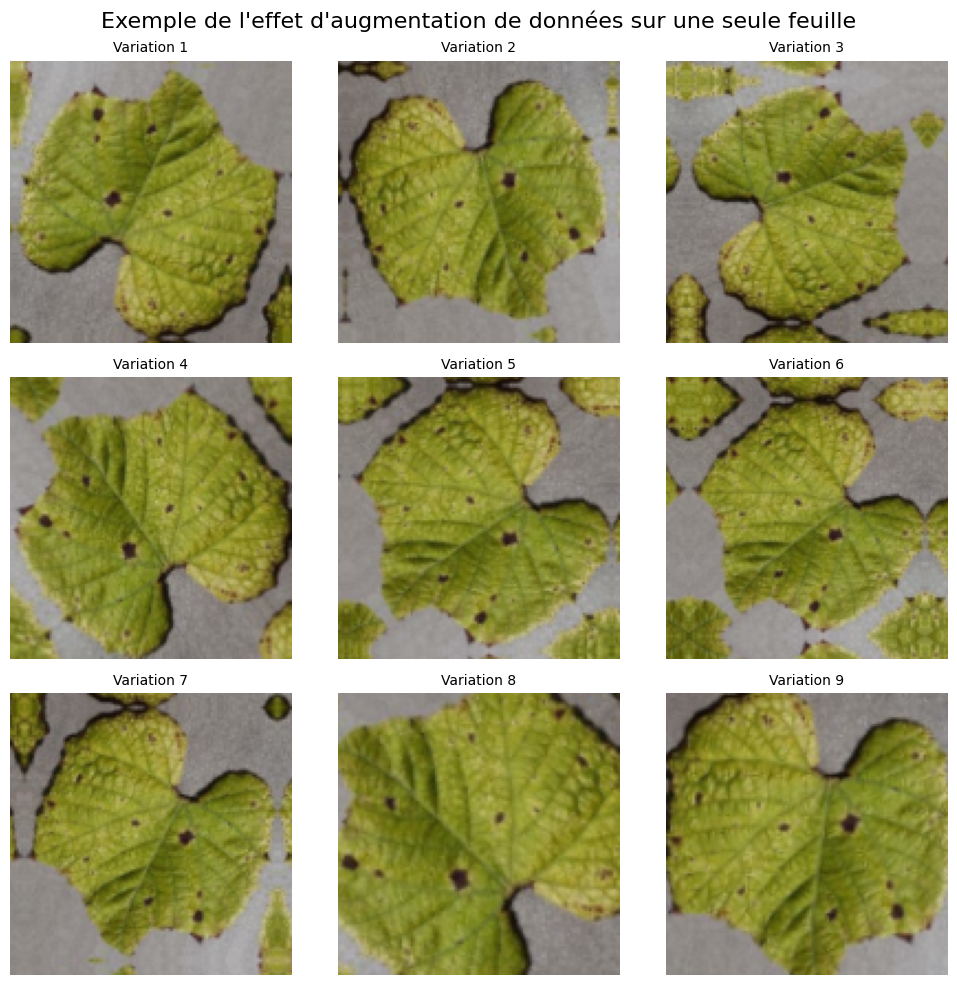

In [ ]:
# Création d'une séquence d'augmentation Keras
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
])

plt.figure(figsize=(10, 10))
for images, _ in training_set.take(1):
    # On isole la première image du batch
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Application de l'augmentation sur l'image
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.title(f"Variation {i+1}", fontsize=10)
        plt.axis("off")
plt.suptitle("Exemple de l'effet d'augmentation de données sur une seule feuille", fontsize=16)
plt.tight_layout()

# Sauvegarde de l'image pour le rapport LaTeX
plt.savefig('augmentation_feuille.png')
plt.show()

# CNN

In [ ]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.models import Sequential

In [ ]:
cnn = Sequential()

In [ ]:
cnn.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(MaxPool2D(pool_size=2,strides=2))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(MaxPool2D(pool_size=2,strides=2))

In [ ]:
cnn.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
cnn.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(MaxPool2D(pool_size=2,strides=2))

In [ ]:
cnn.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
cnn.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(MaxPool2D(pool_size=2,strides=2))

In [ ]:
cnn.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
cnn.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
cnn.add(MaxPool2D(pool_size=2,strides=2))

In [ ]:
cnn.add(Dropout(0.25))

In [ ]:
cnn.add(Flatten())

In [ ]:
cnn.add(Dense(units=1500,activation='relu'))

In [ ]:
cnn.add(Dropout(0.4)) #To avoid overfitting

In [ ]:
cnn.add(Dense(units=38,activation='softmax'))

In [ ]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 126, 126, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 63, 63, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 61, 61, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 30, 30, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1500)                │       3,073,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1500)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │          57,038 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
training_history = cnn.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 168s 69ms/step - accuracy: 0.3791 - loss: 2.2432 - val_accuracy: 0.8225 - val_loss: 0.5763
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 174s 62ms/step - accuracy: 0.8351 - loss: 0.5260 - val_accuracy: 0.8874 - val_loss: 0.3486
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 142s 62ms/step - accuracy: 0.9034 - loss: 0.3005 - val_accuracy: 0.9288 - val_loss: 0.2215
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 143s 65ms/step - accuracy: 0.9321 - loss: 0.2049 - val_accuracy: 0.9455 - val_loss: 0.1716
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 195s 62ms/step - accuracy: 0.9515 - loss: 0.1496 - val_accuracy: 0.9516 - val_loss: 0.1495
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 149s 65ms/step - accuracy: 0.9631 - loss: 0.1133 - val_accuracy: 0.9589 - val_loss: 0.1320
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 195s 62ms/step - accuracy: 0.9702 - loss: 0.0904 - val_accuracy: 0.9587 - val_loss: 0.1372
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 142s 65ms/step - accuracy: 

In [ ]:
train_loss, train_acc = cnn.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 63s 29ms/step - accuracy: 0.9954 - loss: 0.0170


In [ ]:
train_loss

0.9958460927009583

In [ ]:
train_acc

0.9958460927009583

In [ ]:
val_loss, val_acc = cnn.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.9706 - loss: 0.0906


In [ ]:
val_loss

0.09504538029432297

In [ ]:
val_acc

0.970805823802948

In [ ]:
cnn.save('plant_disease_model.h5')

In [ ]:
cnn.save('plant_disease_model.keras')

In [ ]:
# Path to your existing Keras model in .h5 format
h5_model_path = 'Saved models/plant_disease_model.h5'

# Load the Keras model
keras_model = tf.keras.models.load_model(h5_model_path)

# Create a TFLiteConverter object
converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)

# Convert the model to TensorFlow Lite format
tflite_model = converter.convert()

# Path to save the TensorFlow Lite model
tflite_model_path = 'Saved models/plant_disease_model.tflite'

# Save the converted model to a .tflite file
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model)

print(f"Model successfully converted and saved to {tflite_model_path}")

Saved artifact at '/tmp/tmpl_kfeo82'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  138765266842400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138765266879056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138765266887152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138765266889616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138765267028096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138765267031088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138765267033728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138765267036016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138765267040240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138765267039712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13876526722488

In [ ]:
training_history.history

{'accuracy': [0.5800270438194275,
  0.8570737838745117,
  0.9122697114944458,
  0.9373497366905212,
  0.9532683491706848,
  0.9632975459098816,
  0.9706664681434631,
  0.9743651747703552,
  0.9788604974746704,
  0.9817910194396973],
 'loss': [1.430357813835144,
  0.45245856046676636,
  0.2728465795516968,
  0.1908898651599884,
  0.14277996122837067,
  0.11091738939285278,
  0.08910473436117172,
  0.07846059650182724,
  0.06533437967300415,
  0.0577959269285202],
 'val_accuracy': [0.8225017189979553,
  0.8874345421791077,
  0.9287502765655518,
  0.945538341999054,
  0.9515706896781921,
  0.9588549733161926,
  0.9587411880493164,
  0.9688140153884888,
  0.9552128314971924,
  0.970805823802948],
 'val_loss': [0.5763258934020996,
  0.3485998809337616,
  0.22152526676654816,
  0.17157113552093506,
  0.14950044453144073,
  0.13203845918178558,
  0.1372014731168747,
  0.11197878420352936,
  0.15177981555461884,
  0.09504543244838715]}

In [ ]:
epochs = [i for i in range(1,11)]

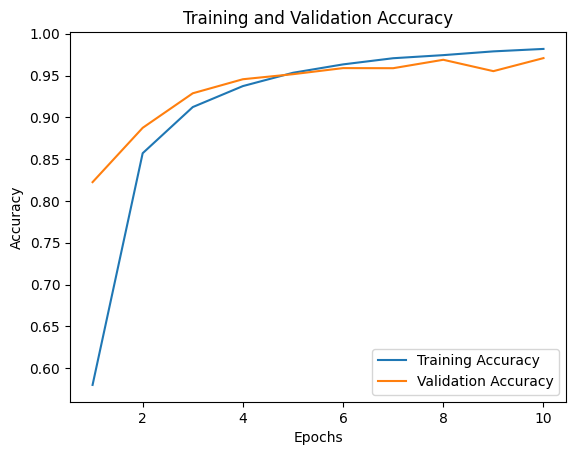

In [ ]:
plt.plot(epochs, training_history.history["accuracy"], label="Training Accuracy")
plt.plot(epochs, training_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

In [ ]:
classes

['Strawberry___healthy',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Apple___Cedar_apple_rust',
 'Pepper,_bell___healthy',
 'Blueberry___healthy',
 'Potato___Early_blight',
 'Raspberry___healthy',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Apple___healthy',
 'Tomato___Early_blight',
 'Soybean___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Grape___Esca_(Black_Measles)',
 'Tomato___Tomato_mosaic_virus',
 'Corn_(maize)___Common_rust_',
 'Grape___healthy',
 'Squash___Powdery_mildew',
 'Potato___healthy',
 'Apple___Black_rot',
 'Strawberry___Leaf_scorch',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Potato___Late_blight',
 'Apple___Apple_scab',
 'Pepper,_bell___Bacterial_spot',
 'Tomato___Target_Spot',
 'Tomato___Bacterial_spot',
 'Tomato___Leaf_Mold',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)__

In [ ]:
test_set = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [ ]:
y_pred = cnn.predict(test_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step


In [ ]:
predicted_classes = tf.argmax(y_pred, axis=1)

In [ ]:
predicted_classes

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [ ]:
y_true = tf.concat([y for x, y in test_set], axis=0)
y_true = tf.argmax(y_true, axis=1)

In [ ]:
y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
print(classification_report(y_true, predicted_classes, target_names=classes))

                                                    precision    recall  f1-score   support

                              Strawberry___healthy       0.97      0.97      0.97       504
     Tomato___Spider_mites Two-spotted_spider_mite       0.99      0.99      0.99       497
               Corn_(maize)___Northern_Leaf_Blight       0.97      0.98      0.98       440
                          Apple___Cedar_apple_rust       0.97      0.97      0.97       502
                            Pepper,_bell___healthy       0.99      0.96      0.97       454
                               Blueberry___healthy       0.98      0.99      0.98       421
                             Potato___Early_blight       0.97      1.00      0.99       456
                               Raspberry___healthy       0.93      0.92      0.93       410
                            Corn_(maize)___healthy       0.98      1.00      0.99       477
                                 Grape___Black_rot       0.95      0.96      0.

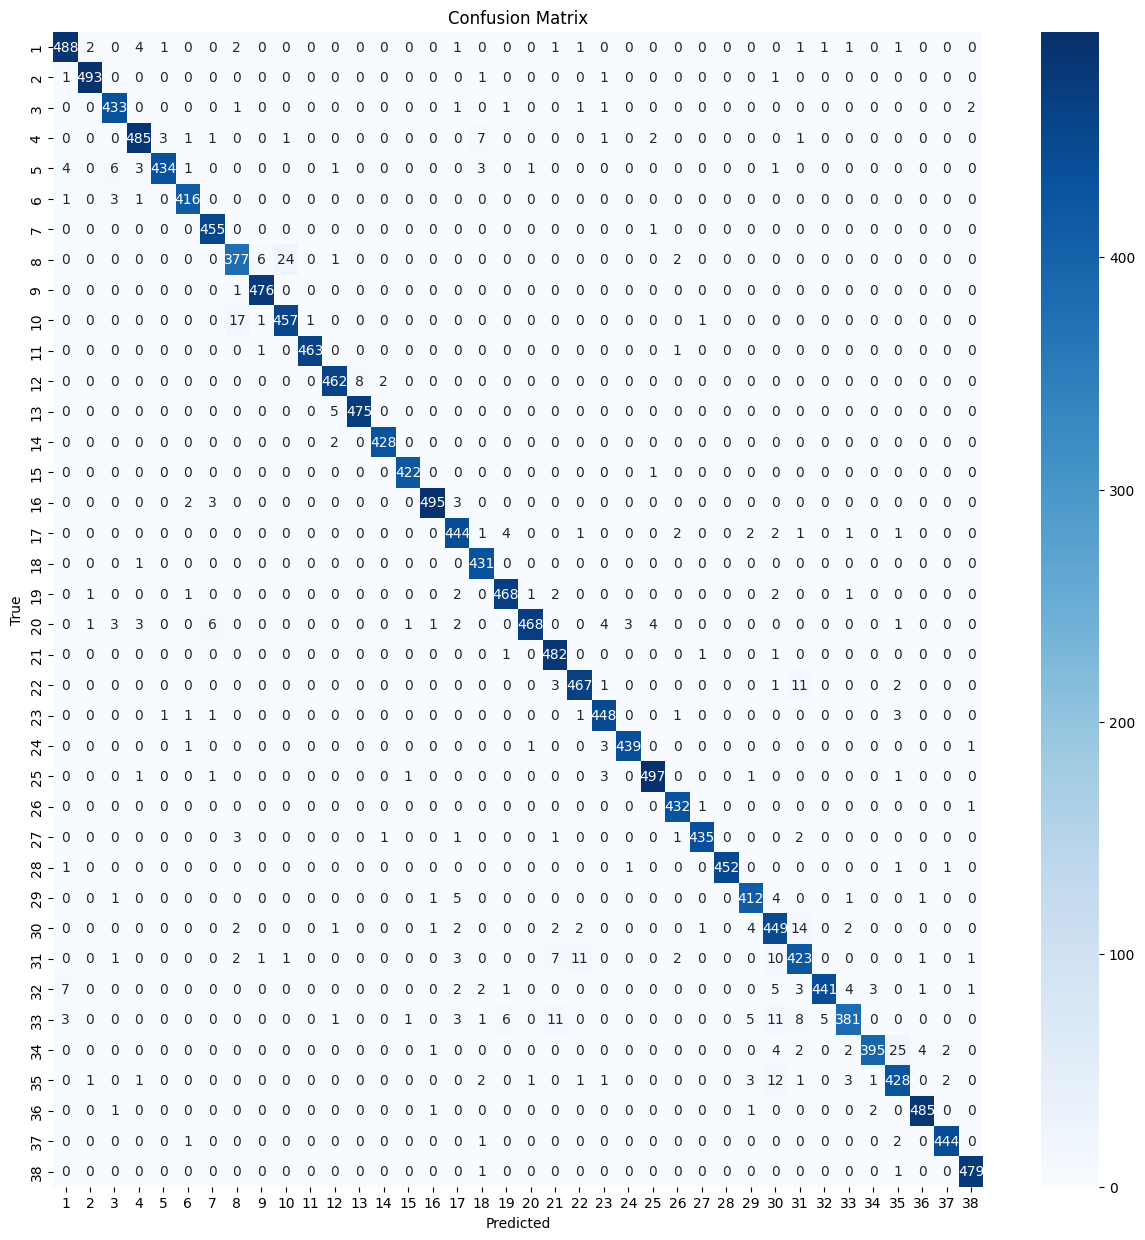

In [ ]:
cm = confusion_matrix(y_true, predicted_classes)

# Plot the confusion matrix
plt.figure(figsize=(15, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[ i for i in range (1,39)], yticklabels=[ i for i in range (1,39)])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# ResNet
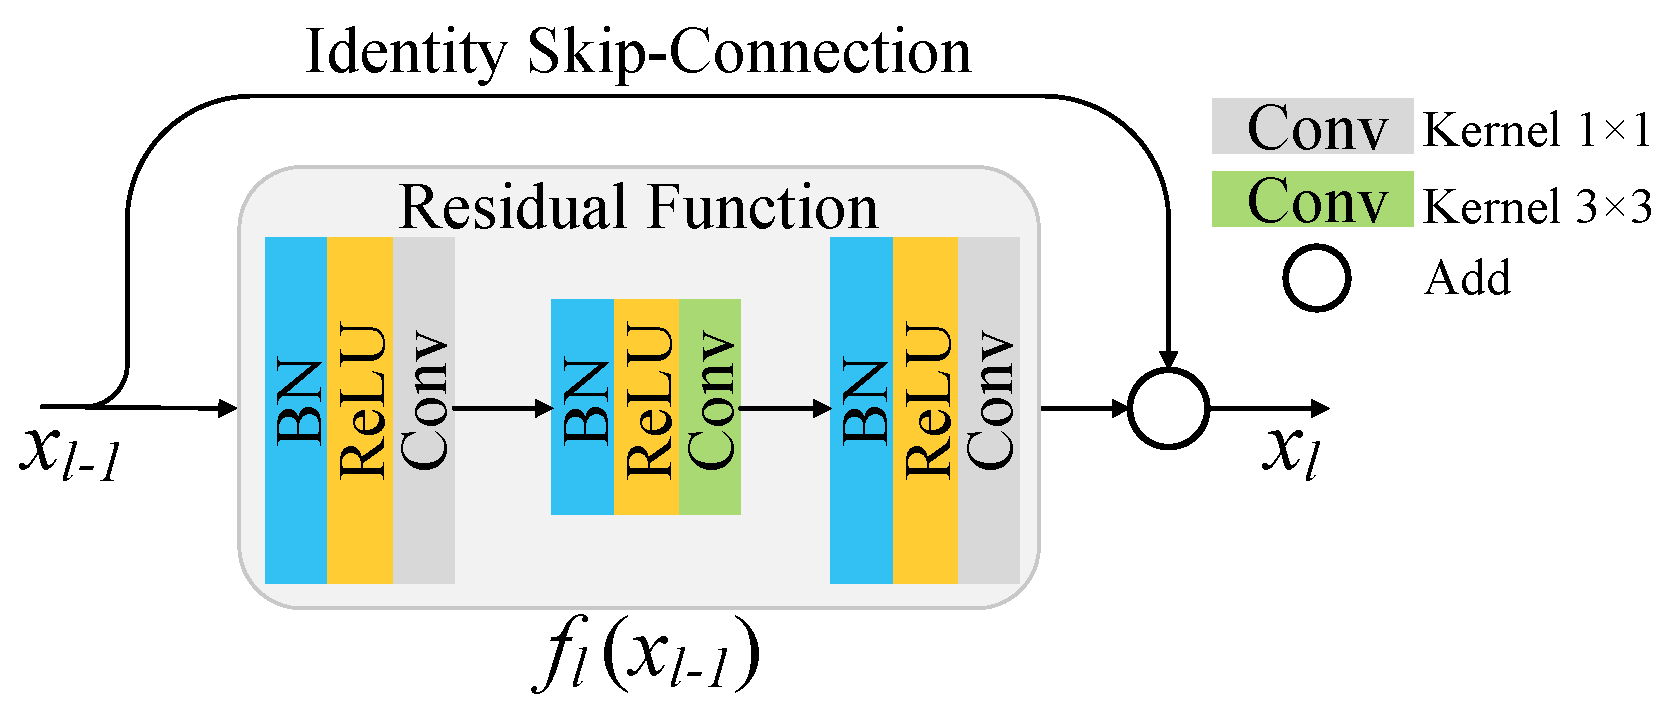

In [ ]:
# defining the model and moving it to the GPU
model = to_device(ResNet9(3, len(train.classes)), device)
model

ResNet9(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (res1): Sequential(
    (0): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=Tr

In [ ]:
# getting summary of the model
INPUT_SHAPE = (3, 256, 256)
print(summary(model.cuda(), (INPUT_SHAPE)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 256, 256]           1,792
       BatchNorm2d-2         [-1, 64, 256, 256]             128
              ReLU-3         [-1, 64, 256, 256]               0
            Conv2d-4        [-1, 128, 256, 256]          73,856
       BatchNorm2d-5        [-1, 128, 256, 256]             256
              ReLU-6        [-1, 128, 256, 256]               0
         MaxPool2d-7          [-1, 128, 64, 64]               0
            Conv2d-8          [-1, 128, 64, 64]         147,584
       BatchNorm2d-9          [-1, 128, 64, 64]             256
             ReLU-10          [-1, 128, 64, 64]               0
           Conv2d-11          [-1, 128, 64, 64]         147,584
      BatchNorm2d-12          [-1, 128, 64, 64]             256
             ReLU-13          [-1, 128, 64, 64]               0
           Conv2d-14          [-1, 256,

In [ ]:
# Architecture for training

# convolution block with BatchNormalization
def ConvBlock(in_channels, out_channels, pool=False):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
             nn.BatchNorm2d(out_channels),
             nn.ReLU(inplace=True)]
    if pool:
        layers.append(nn.MaxPool2d(4))
    return nn.Sequential(*layers)


# resnet architecture
class ResNet9(ImageClassificationBase):
    def __init__(self, in_channels, num_diseases):
        super().__init__()

        self.conv1 = ConvBlock(in_channels, 64)
        self.conv2 = ConvBlock(64, 128, pool=True) # out_dim : 128 x 64 x 64
        self.res1 = nn.Sequential(ConvBlock(128, 128), ConvBlock(128, 128))

        self.conv3 = ConvBlock(128, 256, pool=True) # out_dim : 256 x 16 x 16
        self.conv4 = ConvBlock(256, 512, pool=True) # out_dim : 512 x 4 x 44
        self.res2 = nn.Sequential(ConvBlock(512, 512), ConvBlock(512, 512))

        self.classifier = nn.Sequential(nn.MaxPool2d(4),
                                       nn.Flatten(),
                                       nn.Linear(512, num_diseases))

    def forward(self, xb): # xb is the loaded batch
        out = self.conv1(xb)
        out = self.conv2(out)
        out = self.res1(out) + out
        out = self.conv3(out)
        out = self.conv4(out)
        out = self.res2(out) + out
        out = self.classifier(out)
        return out

In [ ]:
# for training
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)


def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']


def fit_OneCycle(epochs, max_lr, model, train_loader, val_loader, weight_decay=0,
                grad_clip=None, opt_func=torch.optim.SGD):
    torch.cuda.empty_cache()
    history = []

    optimizer = opt_func(model.parameters(), max_lr, weight_decay=weight_decay)
    # scheduler for one cycle learniing rate
    sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs, steps_per_epoch=len(train_loader))


    for epoch in range(epochs):
        # Training
        model.train()
        train_losses = []
        lrs = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()

            # gradient clipping
            if grad_clip:
                nn.utils.clip_grad_value_(model.parameters(), grad_clip)

            optimizer.step()
            optimizer.zero_grad()

            # recording and updating learning rates
            lrs.append(get_lr(optimizer))
            sched.step()


        # validation
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['lrs'] = lrs
        model.epoch_end(epoch, result)
        history.append(result)

    return history


In [ ]:
%%time
history += fit_OneCycle(epochs, max_lr, model, train_dl, valid_dl,
                             grad_clip=grad_clip,
                             weight_decay=1e-4,
                             opt_func=opt_func)

Epoch [0], last_lr: 0.00812, train_loss: 0.7466, val_loss: 0.5865, val_acc: 0.8319
Epoch [1], last_lr: 0.00000, train_loss: 0.1248, val_loss: 0.0269, val_acc: 0.9923
CPU times: user 11min 16s, sys: 7min 13s, total: 18min 30s
Wall time: 19min 53s


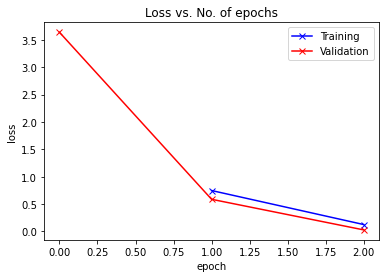

In [ ]:
plot_losses(history)

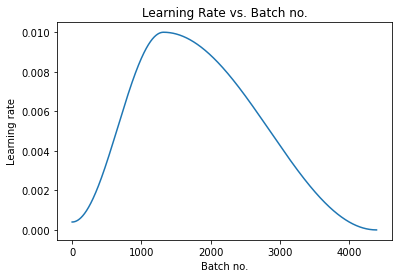

In [ ]:
plot_lrs(history)

Label: AppleCedarRust1.JPG , Predicted: Apple___Cedar_apple_rust


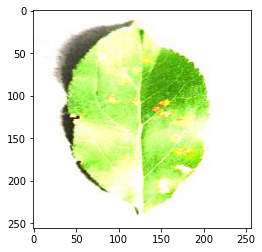

In [ ]:
# predicting first image
img, label = test[0]
plt.imshow(img.permute(1, 2, 0))
print('Label:', test_images[0], ', Predicted:', predict_image(img, model))